In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [111]:
# Q1

In [112]:
df_urb = pd.read_csv('urbanization.csv')
df_urb.head()

,FullGeoName,Location,State,County_name,2023 Code
0,"AK, Aleutians East Borough",2013,AK,Aleutians East Borough,6 - Noncore
1,"AK, Aleutians West Ca",2016,AK,Aleutians West Census Area,6 - Noncore
2,"AK, Anchorage Muny",2020,AK,Anchorage Municipality,3 - Medium metro
3,"AK, Bethel Ca",2050,AK,Bethel Census Area,6 - Noncore
4,"AK, Bristol Bay Borough",2060,AK,Bristol Bay Borough,6 - Noncore


In [113]:
df_urb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3144 entries, 0 to 3143
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   FullGeoName  3144 non-null   object
 1   Location     3144 non-null   int64 
 2   State        3144 non-null   object
 3   County_name  3144 non-null   object
 4   2023 Code    3144 non-null   object
dtypes: int64(1), object(4)
memory usage: 122.9+ KB


In [114]:
df_aqi = pd.read_csv('AQI.csv')
territories = [
    "Virgin Islands",
    "Country Of Mexico",
    "Puerto Rico",
    "Guam",
    "American Samoa",
    "Northern Mariana Islands"
]
df_aqi = aqi[~aqi["State"].isin(territories)]

unhealthy_cols = ['Unhealthy for Sensitive Groups Days', 'Unhealthy Days', 'Very Unhealthy Days', 'Hazardous Days']
df_aqi['Pct_Unhealthy_Days'] = df_aqi[unhealthy_cols].sum(axis=1) * 100 / df_aqi['Days with AQI']

In [115]:
# change AQI.csv's state names to abbreviations so that merge is available
us_state_to_abbreviation = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR", "California": "CA",
    "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE", "Florida": "FL", "Georgia": "GA",
    "Hawaii": "HI", "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS", "Missouri": "MO",
    "Montana": "MT", "Nebraska": "NE", "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ",
    "New Mexico": "NM", "New York": "NY", "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH",
    "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT", "Vermont": "VT",
    "Virginia": "VA", "Washington": "WA", "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY",
    "District of Columbia": "DC", "District Of Columbia": "DC",
}
df_aqi['State_Abbreviated'] = df_aqi['State'].str.strip().map(us_state_to_abbreviation)

# clean AQI.csv's county names so that merge is available
df_aqi['Normalized_County'] = df_aqi['County'].str.strip()\
    .str.replace(r' \(City\)', ' City', regex = False)\
    .str.replace(r'^Saint ', 'St. ', regex = False)\
    .str.replace(r'^Sainte ', 'Ste. ', regex = False)

# clean urbanization.csv's county names so that merge is available
df_urb['County_Cleaned'] = df_urb['County_name'].str.strip()\
    .str.replace(' City and Borough', '', regex = False)\
    .str.replace(' Municipality', '', regex = False)\
    .str.replace(' Census Area', '', regex = False)\
    .str.replace(' Borough', '', regex = False)\
    .str.replace(' Parish', '', regex = False)\
    .str.replace(' County', '', regex = False)\
    .str.replace(' city', ' City', regex = False)

merged_df = pd.merge(df_aqi, df_urb[['State', 'County_Cleaned', '2023 Code']], 
                     left_on = ['State_Abbreviated', 'Normalized_County'], 
                     right_on = ['State', 'County_Cleaned'], 
                     how = 'left')

merged_df = merged_df.rename(columns={'2023 Code': 'Urbanization Score'})
columns_to_drop = ['State_Abbreviated', 'Normalized_County', 'State_y', 'County_Cleaned']
merged_df = merged_df.drop(columns=columns_to_drop)
merged_df['Urbanization Score'] = pd.to_numeric(merged_df['Urbanization Score'].str[0])

merged_df

,State_x,County,Year,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days PM2.5,Days PM10,Pct_Unhealthy_Days,Urbanization Score
0,Alabama,Baldwin,2025,241,174,67,0,0,0,0,87,56,42,0,0,91,150,0,0.000000,4.0
1,Alabama,Clay,2025,239,204,34,1,0,0,0,133,52,32,0,0,0,239,0,0.418410,6.0
2,Alabama,DeKalb,2025,243,191,52,0,0,0,0,93,55,42,0,0,156,87,0,0.000000,5.0
3,Alabama,Elmore,2025,177,172,5,0,0,0,0,64,46,32,0,0,177,0,0,0.000000,3.0
4,Alabama,Etowah,2025,241,153,88,0,0,0,0,87,58,45,0,0,72,169,0,0.000000,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
963,Wyoming,Sublette,2025,242,165,76,1,0,0,0,101,67,47,0,0,240,2,0,0.413223,6.0
964,Wyoming,Sweetwater,2025,212,149,59,4,0,0,0,115,64,45,0,0,164,30,18,1.886792,5.0
965,Wyoming,Teton,2025,226,179,47,0,0,0,0,84,58,45,2,0,221,3,0,0.000000,5.0
966,Wyoming,Uinta,2025,87,87,0,0,0,0,0,50,21,10,0,0,0,0,87,0.000000,5.0


Text(0.5, 1.0, 'Pointplot')

<Figure size 1200x600 with 0 Axes>

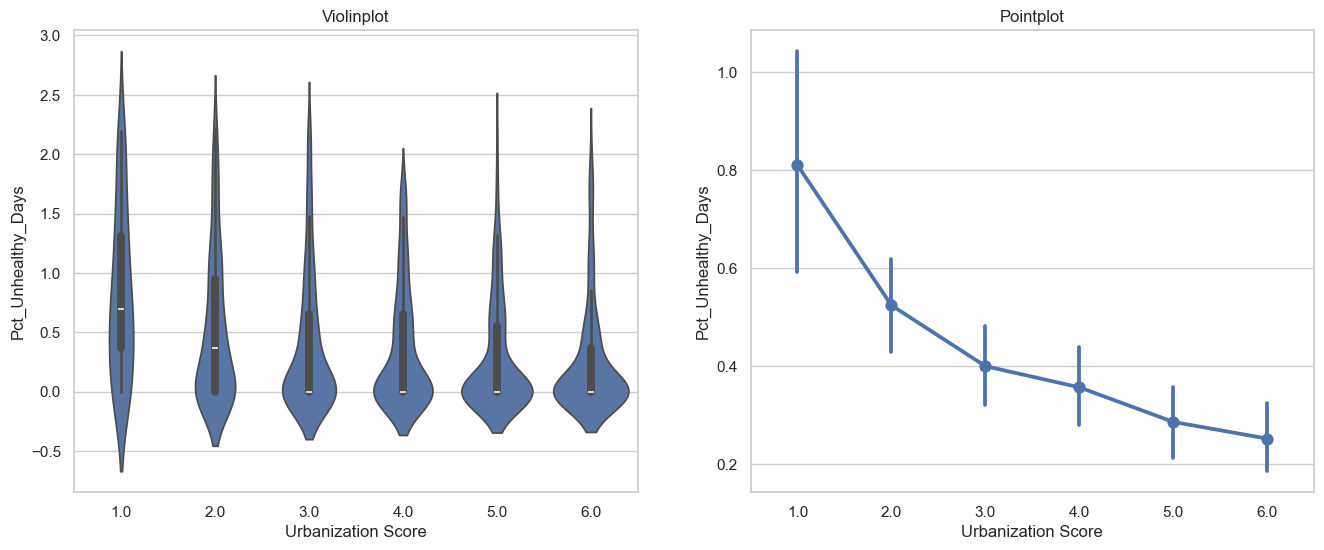

In [116]:
plt.figure(figsize=(12, 6))
sns.set_theme(style = 'whitegrid')

q1 = merged_df['Pct_Unhealthy_Days'].quantile(0.25)
q3 = merged_df['Pct_Unhealthy_Days'].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

merged_df = merged_df[(merged_df['Pct_Unhealthy_Days'] >= lower_limit) & (merged_df['Pct_Unhealthy_Days'] <= upper_limit)]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(16, 6))

sns.violinplot(x = 'Urbanization Score', y = 'Pct_Unhealthy_Days', data = merged_df, ax = ax0)
ax0.set_title('Violinplot')

sns.pointplot(x = 'Urbanization Score', y = 'Pct_Unhealthy_Days', data = merged_df, ax = ax1)
ax1.set_title('Pointplot')

In [117]:
# Q2

In [118]:
df_svi = pd.read_csv('SVI.csv')
df_svi.head()

,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,1,Alabama,AL,1001,Autauga County,1001,"Autauga County, Alabama",594.454786,58761,0,...,1.1,0.4,0.1,0.1,0.0,0.1,3.3,1.0,0.2,0.3
1,1,Alabama,AL,1003,Baldwin County,1003,"Baldwin County, Alabama",1589.861817,233420,0,...,0.9,0.1,0.2,0.1,0.0,0.1,3.1,0.4,0.4,0.3
2,1,Alabama,AL,1005,Barbour County,1005,"Barbour County, Alabama",885.007619,24877,0,...,0.5,0.1,0.3,0.1,0.0,0.1,1.8,0.7,1.2,0.8
3,1,Alabama,AL,1007,Bibb County,1007,"Bibb County, Alabama",622.469286,22251,0,...,0.3,0.4,0.1,0.1,0.0,0.2,1.7,1.0,0.1,0.1
4,1,Alabama,AL,1009,Blount County,1009,"Blount County, Alabama",644.890376,59077,0,...,0.2,0.2,0.1,0.1,0.2,0.2,2.8,0.7,0.1,0.1


In [119]:
ahvi_columns = ['EPL_AGE65', 'EPL_AGE17', 'EPL_POV150', 'EPL_UNINSUR', 'EPL_DISABL']
df_svi['AHVI'] = df_svi[ahvi_columns].mean(axis=1)

correlation = df_svi['AHVI'].corr(df_svi['RPL_THEMES'])
print(correlation)

0.6249044974924078


In [120]:
cedar = df_svi[(df_svi['COUNTY'] == 'Cedar County') & (df_svi['STATE'] == 'Missouri')].iloc[0]

ahvi_rank = (df_svi['AHVI'] < cedar['AHVI']).mean() * 100
svi_rank = (df_svi['RPL_THEMES'] < cedar['RPL_THEMES']).mean() * 100

print(ahvi_rank, svi_rank)

99.87277353689568 66.41221374045801


In [121]:
df_svi['State_Cleaned'] = df_svi['STATE'].str.strip()

df_svi['County_Cleaned'] = df_svi['COUNTY'].str.strip()\
    .str.replace(' City and Borough', '', regex=False)\
    .str.replace(' Municipality', '', regex=False)\
    .str.replace(' Census Area', '', regex=False)\
    .str.replace(' Borough', '', regex=False)\
    .str.replace(' Parish', '', regex=False)\
    .str.replace(' County', '', regex=False)\
    .str.replace(' city', ' City', regex=False)

merged_df1 = pd.merge(merged_df, df_svi[['State_Cleaned', 'County_Cleaned', 'AHVI']], 
                     left_on=['State_x', 'County'], 
                     right_on=['State_Cleaned', 'County_Cleaned'], 
                     how='left')

merged_df1 = merged_df1.drop(columns=['State_Cleaned', 'County_Cleaned'])
merged_df1

,State_x,County,Year,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,...,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days PM2.5,Days PM10,Pct_Unhealthy_Days,Urbanization Score,AHVI
0,Alabama,Baldwin,2025,241,174,67,0,0,0,0,...,56,42,0,0,91,150,0,0.000000,4.0,0.44582
1,Alabama,Clay,2025,239,204,34,1,0,0,0,...,52,32,0,0,0,239,0,0.418410,6.0,0.59446
2,Alabama,DeKalb,2025,243,191,52,0,0,0,0,...,55,42,0,0,156,87,0,0.000000,5.0,0.65204
3,Alabama,Elmore,2025,177,172,5,0,0,0,0,...,46,32,0,0,177,0,0,0.000000,3.0,0.37110
4,Alabama,Etowah,2025,241,153,88,0,0,0,0,...,58,45,0,0,72,169,0,0.000000,4.0,0.59600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,Wyoming,Sublette,2025,242,165,76,1,0,0,0,...,67,47,0,0,240,2,0,0.413223,6.0,0.49100
886,Wyoming,Sweetwater,2025,212,149,59,4,0,0,0,...,64,45,0,0,164,30,18,1.886792,5.0,0.49944
887,Wyoming,Teton,2025,226,179,47,0,0,0,0,...,58,45,2,0,221,3,0,0.000000,5.0,0.22180
888,Wyoming,Uinta,2025,87,87,0,0,0,0,0,...,21,10,0,0,0,0,87,0.000000,5.0,0.50270


In [122]:
top_vulnerable = df_svi[['STATE', 'COUNTY', 'AHVI', 'RPL_THEMES']].sort_values(by='AHVI', ascending=False)

print("Top 10 U.S. Counties Most Vulnerable to Air Quality Health Impacts:")
print(top_vulnerable.head(20).to_string(index=False))

Top 10 U.S. Counties Most Vulnerable to Air Quality Health Impacts:
      STATE               COUNTY    AHVI  RPL_THEMES
      Texas        Kenedy County 0.93458      0.6678
      Texas          Real County 0.92764      0.7830
   Oklahoma          Coal County 0.86018      0.8358
   Missouri         Cedar County 0.85692      0.6643
   Missouri        Oregon County 0.85086      0.6589
   Oklahoma     Jefferson County 0.84460      0.8056
      Texas        Cottle County 0.84110      0.6732
      Texas      Presidio County 0.83766      0.9933
   Oklahoma       Choctaw County 0.83656      0.9485
    Alabama        Greene County 0.82836      0.9157
   Nebraska        Garden County 0.82604      0.4200
   Oklahoma    Pushmataha County 0.82004      0.8896
Mississippi      Lawrence County 0.81500      0.8505
Mississippi     Humphreys County 0.81472      0.9787
      Texas San Augustine County 0.81462      0.9885
   Missouri        Morgan County 0.80930      0.8657
    Georgia      Treutlen Count

Text(0, 0.5, 'Percentage of Unhealthy Days (%)')

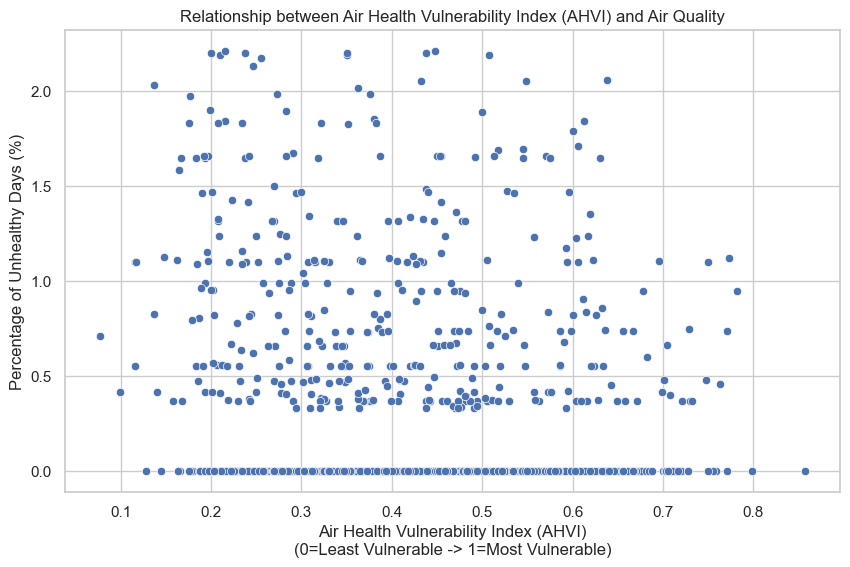

In [123]:
plt.figure(figsize = (10, 6))
sns.set_theme(style = "whitegrid")

sns.scatterplot(x = 'AHVI', y = 'Pct_Unhealthy_Days', data =  merged_df1)

plt.title('Relationship between Air Health Vulnerability Index (AHVI) and Air Quality')
plt.xlabel('Air Health Vulnerability Index (AHVI)\n(0=Least Vulnerable -> 1=Most Vulnerable)')
plt.ylabel('Percentage of Unhealthy Days (%)')

In [124]:
merged_df1['Risk_Score'] = merged_df1['Pct_Unhealthy_Days'] * merged_df1['AHVI']

dangerous_areas = merged_df1[
    ['State_x', 
     'County', 
     'Risk_Score', 
     'Pct_Unhealthy_Days', 
     'AHVI']
    ].sort_values(by='Risk_Score', ascending=False)

print(dangerous_areas.head(10).to_string(index = False))

 State_x    County  Risk_Score  Pct_Unhealthy_Days    AHVI
   Texas   Cameron    1.313004            2.057613 0.63812
 Georgia  Muscogee    1.127059            1.838235 0.61312
   Texas     Bexar    1.124016            2.049180 0.54852
Arkansas   Pulaski    1.111971            2.189781 0.50780
  Kansas Wyandotte    1.071750            1.785714 0.60018
   Texas   Hidalgo    1.036774            1.646091 0.62984
Nebraska      Knox    1.036410            1.709402 0.60630
  Oregon      Lane    0.988597            2.209945 0.44734
 Florida     Duval    0.961934            2.197802 0.43768
   Texas      Bell    0.946798            1.646091 0.57518
